# 04 — 2PACF: IRAC-Detected Sample

This notebook computes the 2PACF for the **IRAC-detected (masked)** sub-sample.
With only 29 galaxies confirmed as IRAC-detected, this sample is too small to
yield statistically robust clustering measurements, but it provides an upper limit
and qualitative comparison with the footprint sample.

All steps are identical to notebook 03 — only the `SAMPLE` variable changes.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import healsparse
from astropy.table import Table

from src.config import cfg, resolve_path
from src.catalog import load_fits_catalog, filter_radec_range, apply_sky_mask, get_radec
from src.randoms import generate_random_catalog
from src.correlation import compute_2pacf, CorrelationResult
from src.plotting import plot_2pacf, plot_sky_distribution

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

SAMPLE = "edf_s_irac_detected"

## 1. Load and filter

In [2]:
sample_cfg  = cfg["samples"][SAMPLE]
cols        = cfg["columns"]
field_name  = sample_cfg["field"]
irac_filter = sample_cfg.get("irac_filter", "none")
survey      = cfg["fields"][field_name]

table = load_fits_catalog(str(resolve_path(cfg["paths"]["raw_catalog"])))

# IRAC filter
if irac_filter == "footprint":
    sel = np.asarray(table[cols["irac_footprint"]], dtype=bool)
    table = table[sel]
elif irac_filter == "detected":
    sel = np.asarray(table[cols["irac_detected"]], dtype=bool)
    table = table[sel]
elif irac_filter == "no_footprint":
    sel = ~np.asarray(table[cols["irac_footprint"]], dtype=bool)
    table = table[sel]
print(f"After IRAC filter ({irac_filter}): {len(table):,} rows")

table = filter_radec_range(
    table,
    ra_min=survey["ra_min"],  ra_max=survey["ra_max"],
    dec_min=survey["dec_min"], dec_max=survey["dec_max"],
    ra_col=cols["ra"], dec_col=cols["dec"],
)
print(f"After sky cut : {len(table):,}")

# HealSparse mask (if defined for this field)
mask_rel = survey.get("mask_healsparse")
if sample_cfg.get("apply_mask", False) and mask_rel:
    import healsparse
    mask_path = str(resolve_path(mask_rel))
    mask_map  = healsparse.HealSparseMap.read(mask_path)
    nside     = mask_map.nside_sparse
    table     = apply_sky_mask(table, mask_map, nside, ra_col=cols["ra"], dec_col=cols["dec"])
    print(f"After mask    : {len(table):,}  ← very small sample")
else:
    print("No mask applied")

ra, dec = get_radec(table, ra_col=cols["ra"], dec_col=cols["dec"])

Loaded catalog: /home/k3vinpaul/LRDs/data/raw/LRD_MarIRAC.fits
  Objects : 3,341
  Columns : ['ID', 'RA', 'DEC', 'z', 'z_err', 'MUV', 'MUV_err', 'beta_UV', 'beta_UV_err', 'beta_opt', 'beta_opt_err', 'IRAC-detected', 'IRAC-footprint']
After IRAC filter (detected): 29 rows
Sky cut [55.0,67.5] × [-52.5,-44.5]: 20 / 29 objects kept
After sky cut : 20
Mask applied: 16 / 20 objects kept (80.0%)
After mask    : 16  ← very small sample
  RA  range : 56.6308 – 64.6499 deg
  Dec range : -50.7894 – -45.8302 deg


## 2. Sky positions of IRAC-detected galaxies

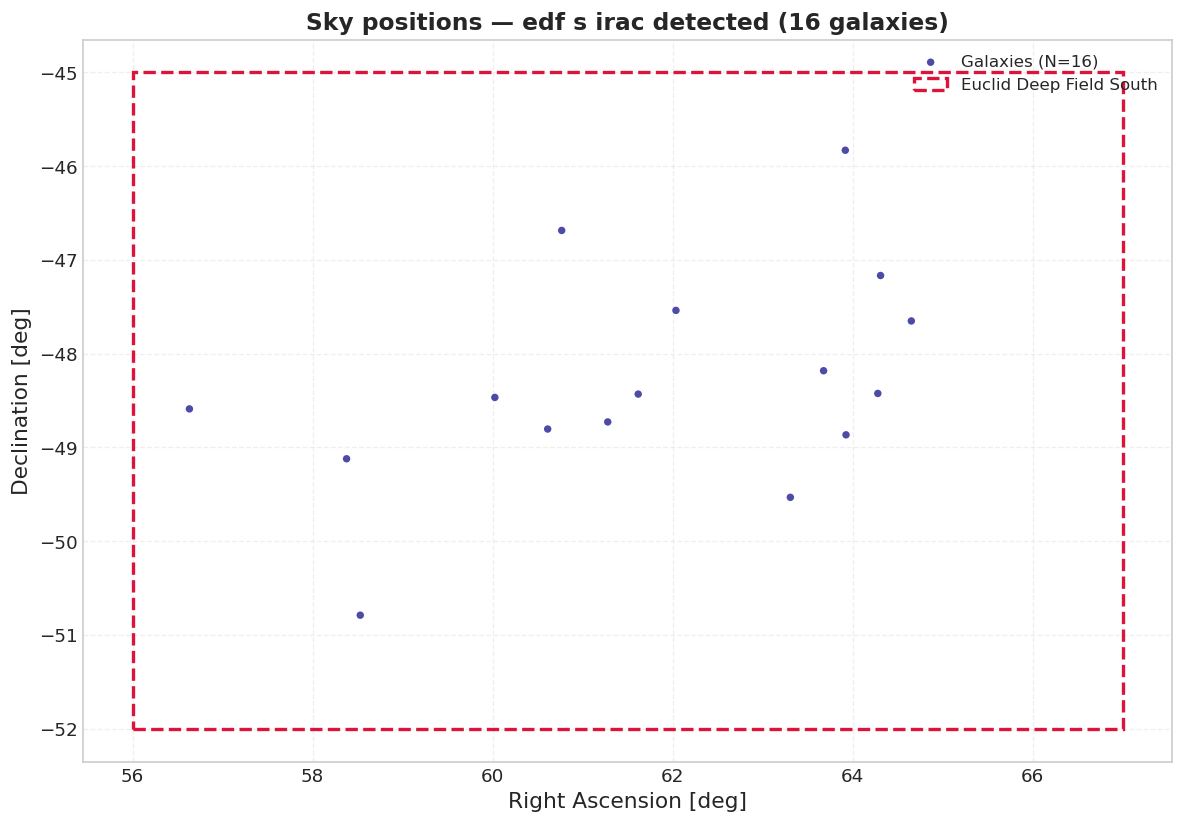

In [3]:
fig, ax = plot_sky_distribution(
    ra, dec,
    title=f"Sky positions — {SAMPLE.replace('_', ' ')} ({len(ra)} galaxies)",
    show_edfs_box=True,
)
plt.show()

## 3. Load or generate randoms

In [4]:
rand_path = resolve_path(f"data/processed/randoms_{SAMPLE}.fits")

if rand_path.exists():
    rand     = Table.read(str(rand_path))
    ra_rand  = np.asarray(rand["RA"])
    dec_rand = np.asarray(rand["DEC"])
    print(f"Loaded cached randoms: {len(ra_rand):,}")
else:
    print("Generating randoms …")
    factor     = cfg["randoms"]["n_randoms_factor"]
    rand_table = generate_random_catalog(
        mask_map=mask_map, nside=nside,
        n_randoms=factor * len(ra),
        ra_min=survey["ra_min"],  ra_max=survey["ra_max"],
        dec_min=survey["dec_min"], dec_max=survey["dec_max"],
        batch_factor=cfg["randoms"]["batch_factor"],
        seed=cfg["randoms"]["seed"],
    )
    rand_table.write(str(rand_path), format="fits", overwrite=True)
    ra_rand  = np.asarray(rand_table["RA"])
    dec_rand = np.asarray(rand_table["DEC"])
    print(f"Generated {len(ra_rand):,} randoms → {rand_path}")

Generating randoms …
Generating 1,600 masked random points …
  batch: 5,364 accepted  (total so far: 5,364)
Done. 1,600 random points generated (mask acceptance rate: 10.0%)
Generated 1,600 randoms → /home/k3vinpaul/LRDs/data/processed/randoms_edf_s_irac_detected.fits


## 4. Compute or load 2PACF

In [5]:
bins      = cfg["bins"]
corr_path = resolve_path(cfg["paths"]["corr_dir"]) / f"2pacf_{SAMPLE}.npz"

if corr_path.exists():
    result = CorrelationResult.load(str(corr_path))
    print(f"Loaded pre-computed 2PACF: {corr_path.name}")
else:
    print("Computing 2PACF …")
    result = compute_2pacf(
        ra, dec, ra_rand, dec_rand,
        min_sep=bins["min_sep"],
        max_sep=bins["max_sep"],
        nbins=bins["nbins"],
        sep_units=bins["sep_units"],
        bin_slop=bins["bin_slop"],
    )
    corr_path.parent.mkdir(parents=True, exist_ok=True)
    result.save(str(corr_path))
    print(f"Saved → {corr_path}")

Computing 2PACF …
  Computing DD … 90 pairs
  Computing DR … 17,483 pairs
  Computing RR … 795,162 pairs
  w(θ) computed: 6/15 valid bins (w range: -0.1316 – 0.2822)
Saved 2PACF result → /home/k3vinpaul/LRDs/results/correlation_functions/2pacf_edf_s_irac_detected.npz
Saved → /home/k3vinpaul/LRDs/results/correlation_functions/2pacf_edf_s_irac_detected.npz


## 5. Results

In [6]:
print(f"{'θ [arcmin]':>12}  {'w(θ)':>12}  {'σ_Poisson':>12}  {'DD pairs':>10}")
print("-" * 52)
for i in range(len(result.theta_arcmin)):
    w   = result.w[i]
    err = result.w_err_poisson[i]
    print(f"{result.theta_arcmin[i]:12.3f}  {w:12.5f}  {err:12.5f}  {result.DD[i]:10.0f}")

  θ [arcmin]          w(θ)     σ_Poisson    DD pairs
----------------------------------------------------
       0.657       1.00000           nan           0
       0.975      -6.40278           nan           0
       1.445      -2.33125           nan           0
       2.142      -2.87355           nan           0
       3.174      -0.86799           nan           0
       4.706      -1.08783           nan           0
       6.976      -0.92930           nan           0
      10.340      -1.02390           nan           0
      15.328      -1.18310           nan           0
      24.441       0.18854       0.77089           2
      30.235       0.28225       0.56618           4
      48.710       0.08847       0.39433           7
      76.620      -0.13162       0.24905          14
     111.242       0.10726       0.19540          29
     161.563      -0.00680       0.17091          34


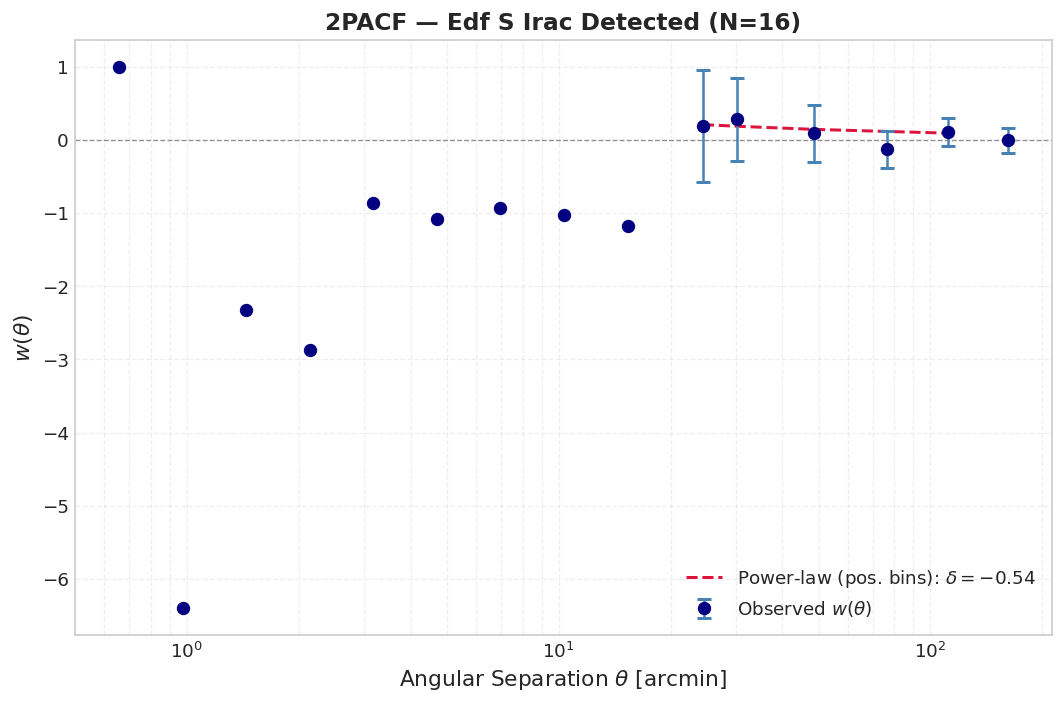

In [7]:
fig, ax = plot_2pacf(
    result,
    title=f"2PACF — {SAMPLE.replace('_', ' ').title()} (N={len(ra)})",
    label="Observed $w(\\theta)$",
    fit_powerlaw=True,
)
plt.show()

## 6. Signal-to-noise assessment

In [8]:
valid = result.valid
if valid.sum() > 0:
    snr = result.w[valid] / result.w_err_poisson[valid]
    print("Bin-by-bin S/N for positive w bins:")
    for i in np.where(valid)[0]:
        s = result.w[i] / result.w_err_poisson[i]
        print(f"  θ = {result.theta_arcmin[i]:.2f} arcmin  →  S/N = {s:.2f}")
else:
    print("No positive w bins — S/N not defined. Sample too small for a robust signal.")

Bin-by-bin S/N for positive w bins:
  θ = 24.44 arcmin  →  S/N = 0.24
  θ = 30.23 arcmin  →  S/N = 0.50
  θ = 48.71 arcmin  →  S/N = 0.22
  θ = 76.62 arcmin  →  S/N = -0.53
  θ = 111.24 arcmin  →  S/N = 0.55
  θ = 161.56 arcmin  →  S/N = -0.04


## Summary

With only ~29 IRAC-detected LRDs in the masked footprint, individual bin S/N values
are typically $<2$. The measurement is noise-dominated and should be interpreted with
caution. The simulation-based error analysis in notebook 05 will provide a more
reliable uncertainty characterisation.

Proceed to **05_error_estimation** to compare Poisson vs simulation error bars.